In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
path='/glade/work/acruz/Caribbean_Heat_data/ERA5/'
hi_clim = xr.open_dataset(path+'HI_dmaxclim.nc')
hi_clim

<xarray.Dataset> Size: 478kB
Dimensions:            (month: 12, latitude: 82, longitude: 121)
Coordinates:
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude           (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude          (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
Data variables:
    HI_daily_max_clim  (month, latitude, longitude) float32 476kB ...

In [10]:
rh_clim = xr.open_dataset(path+'ERA5_clim_RH.nc')
rh_clim_aream = rh_clim.mean('latitude').mean('longitude')
rh_clim_aream = rh_clim_aream['__xarray_dataarray_variable__']

In [11]:
hi_area_mean = hi_clim['HI_daily_max_clim'].mean('latitude').mean('longitude')

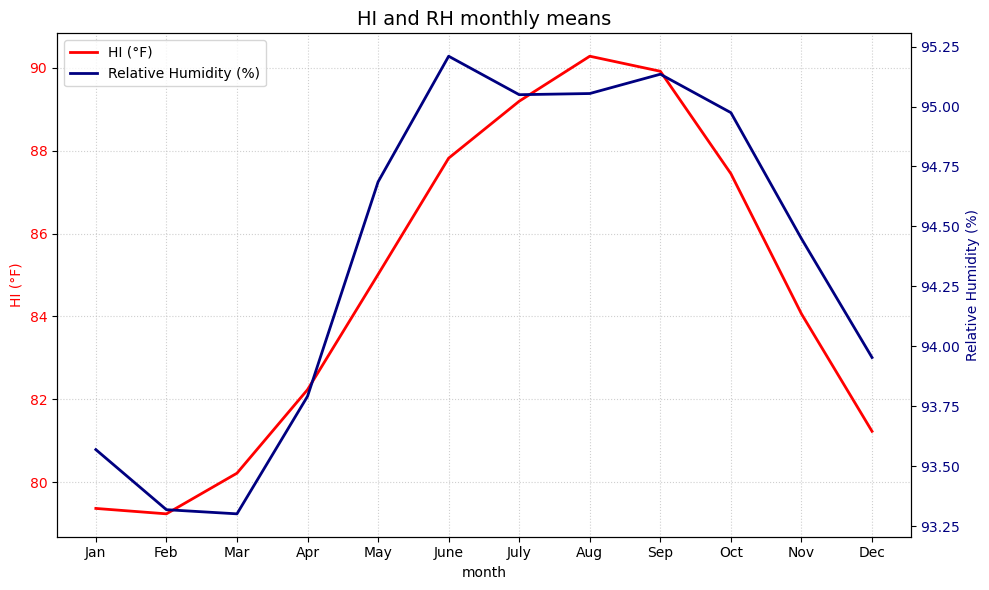

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 6))

hi_area_mean.plot(ax=ax1, label="HI (°F)", color="red", linewidth=2)

ax1.set_ylabel("HI (°F)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()

rh_clim_aream.plot(ax=ax2, label="Relative Humidity (%)", color="navy", linewidth=2)
ax2.set_ylabel("Relative Humidity (%)", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")

plt.title("HI and RH monthly means", fontsize=14)
ax1.grid(True, linestyle=":", alpha=0.6)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=np.arange(1,13,1), labels=months)

plt.tight_layout()
plt.show()